#HW1 - Data Exploration and Preparation

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from matplotlib import pylab
params = {'xtick.labelsize': 18,
          'ytick.labelsize': 18,
          'axes.titlesize' : 22,
          'axes.labelsize' : 20,
          'legend.fontsize': 18,
          'legend.title_fontsize': 22,
          'figure.titlesize': 24 }
pylab.rcParams.update(params)

## Loading the dataset

In [30]:
!rm *.csv

from google.colab import files
print("Please load the raw csv data")
uploadedData = files.upload()
filename = list(uploadedData)[0]

Please load the raw csv data


Saving virus_data.csv to virus_data.csv


In [31]:
dataset = pd.read_csv(filename)

#(Q1) rows and columns are in the dataset

In [32]:
dataset.shape

(1250, 25)

#(Q2)Print the value_counts of the conversations_per_day feature

In [33]:
dataset["conversations_per_day"].value_counts()

,count
conversations_per_day,
2,220
4,207
3,201
5,153
6,125
1,115
7,77
8,52
10,33


#(Q4) train_test_split

In [34]:
from sklearn.model_selection import train_test_split

#split the dataset
train, test = train_test_split(dataset, test_size=0.2, train_size=0.8, random_state=74)

# For the last task, since we might change train and/or test in the next tasks
train_df = train.copy()
test_df = test.copy()

#(Q5)missing values

In [35]:
train.isnull().sum()

,0
patient_id,0
age,0
sex,0
weight,0
blood_type,0
current_location,0
num_of_siblings,0
happiness_score,0
household_income,115
PCR_02,61


In [36]:
# sum of missing values in each col = total missing values
total_missing_value_train = train.isnull().sum().sum()
print(f"Total missing values in the training set: {total_missing_value_train}")

Total missing values in the training set: 176


In [37]:
test.isnull().sum()

,0
patient_id,0
age,0
sex,0
weight,0
blood_type,0
current_location,0
num_of_siblings,0
happiness_score,0
household_income,24
PCR_02,13


In [38]:
total_missing_value_test = test.isnull().sum().sum()
print(f"Total missing values in the test set: {total_missing_value_test}")

Total missing values in the test set: 37


#(Q6) create a box plot

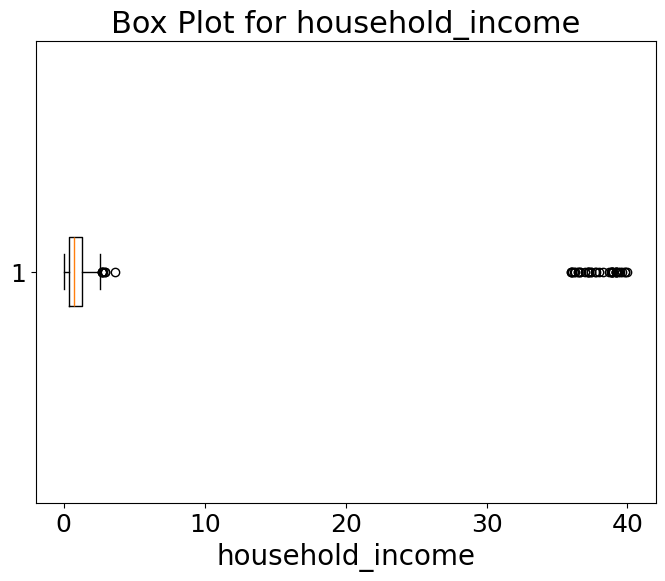

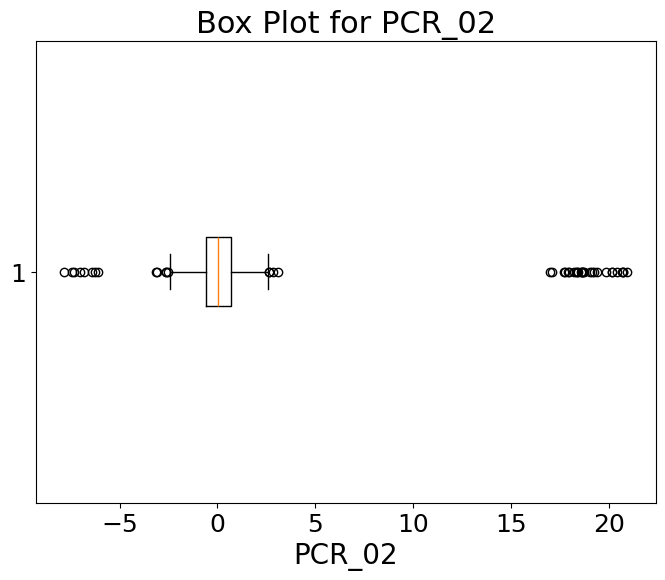

In [39]:
def plot_box(series, title, xlabel):
    cleaned_series = series.dropna()
    plt.figure(figsize=(8, 6))
    plt.boxplot(cleaned_series, vert=False)
    plt.xlabel(xlabel)
    plt.title(title)

# fields that contain null vals
fields = train.columns[train.isnull().any()]

# iterate over them, box plot each field
for field in fields:
    plot_box(train[field], title=f"Box Plot for {field}", xlabel=field)

#(Q7) calculate the median and the mean in the training set

In [40]:
# calc mean and median for each field with null vals
for field in fields:
    train_mean = train[field].mean()
    train_median = train[field].median()
    print(f"{field}: mean = {train_mean}, median = {train_median}")

household_income: mean = 2.4109604519774015, median = 0.7
PCR_02: mean = 0.5007548379418331, median = 0.037797112465529


# Task A

In [41]:
# fill each field's NA values with train's median vakue for field
for field in fields:
    median_value = train[field].median()
    train[field] = train[field].fillna(median_value)
    test[field] = test[field].fillna(median_value)

# Task B, (Q8)

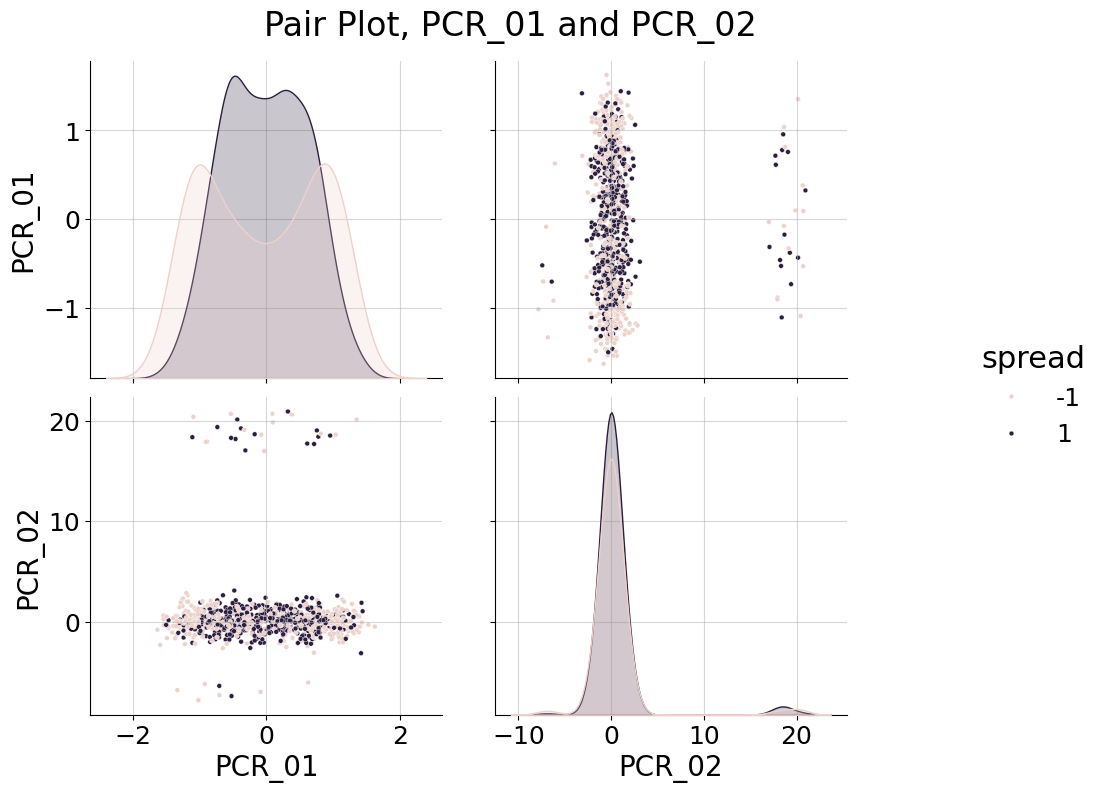

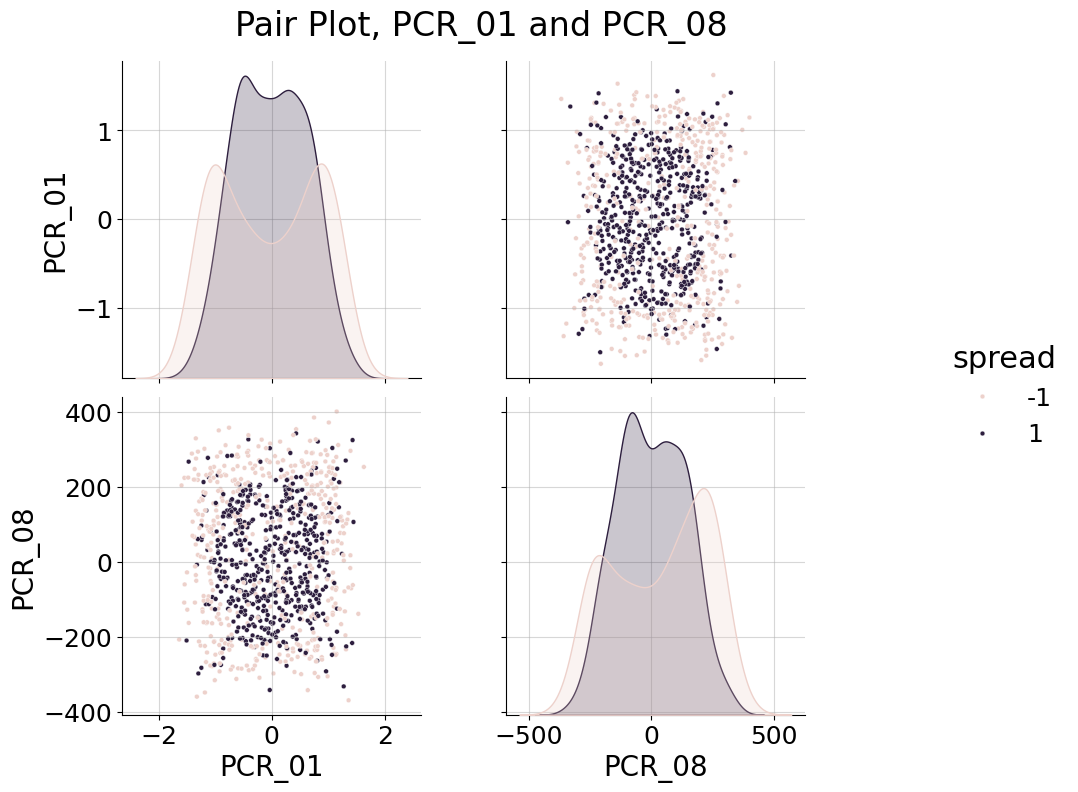

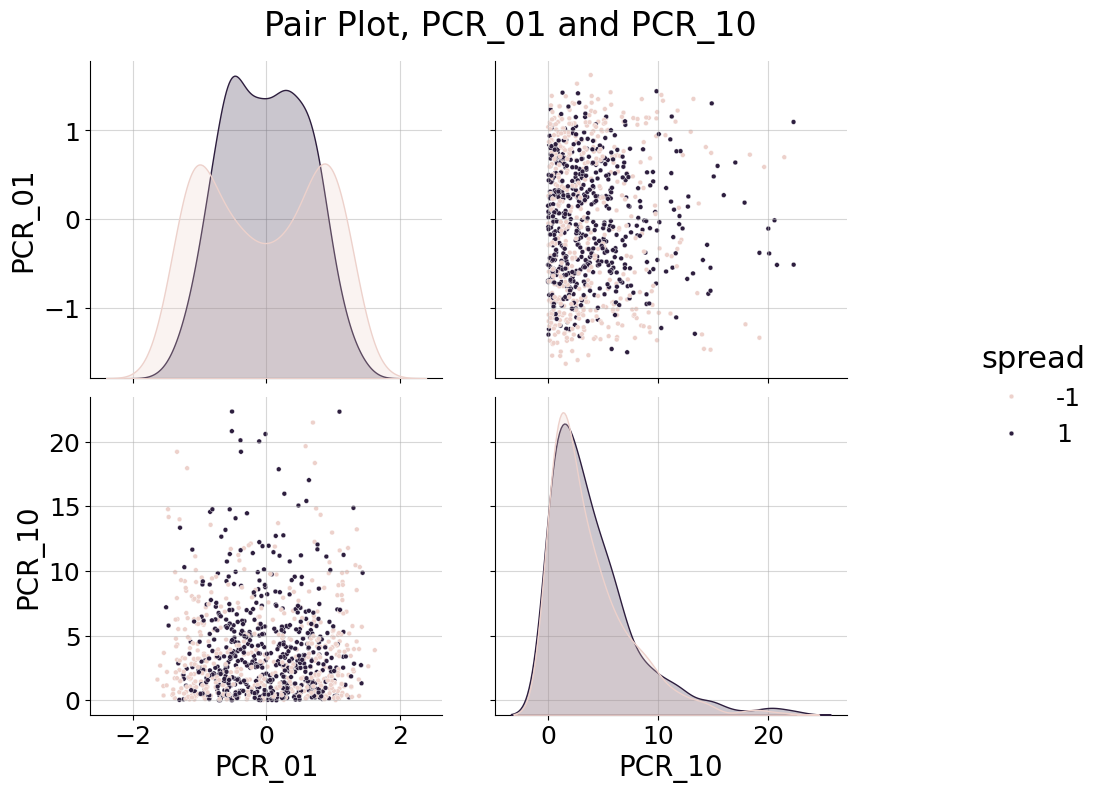

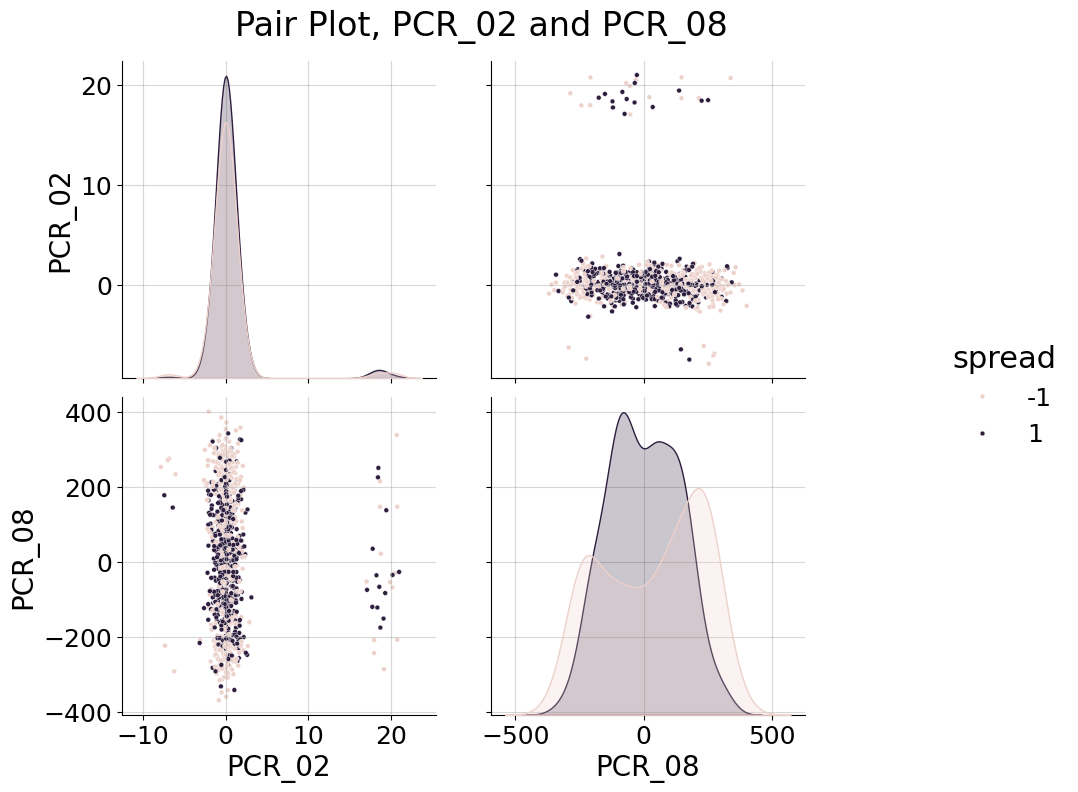

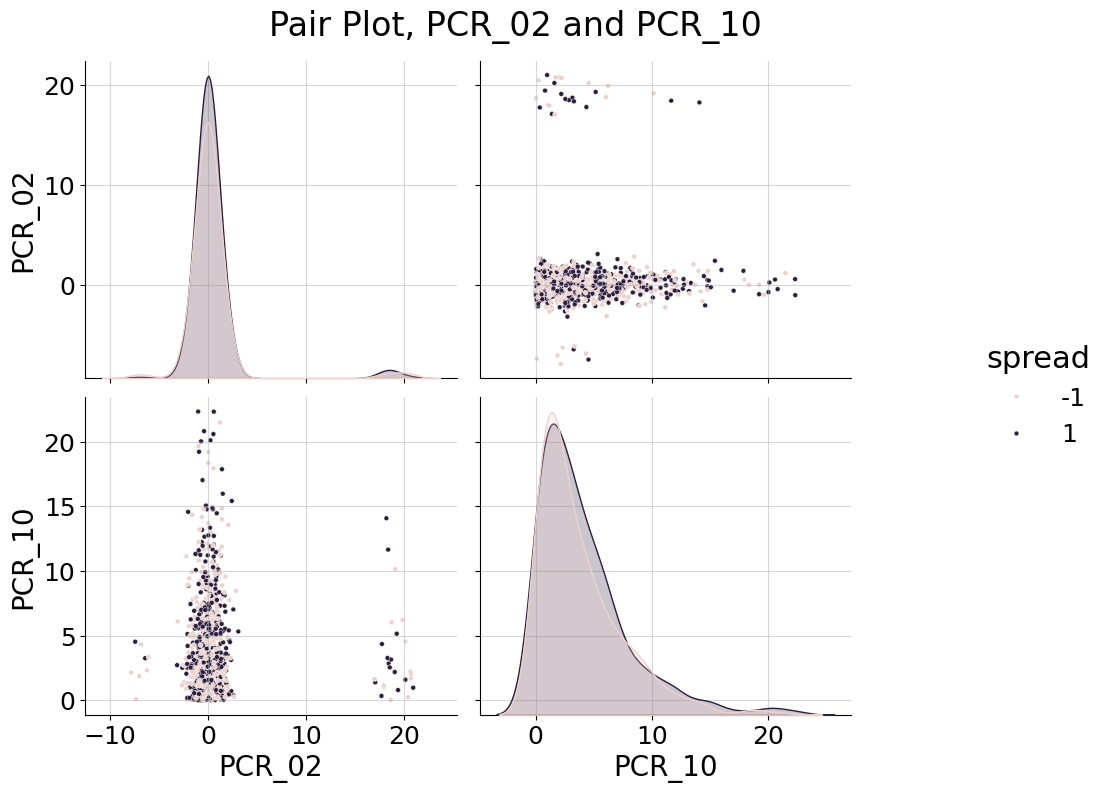

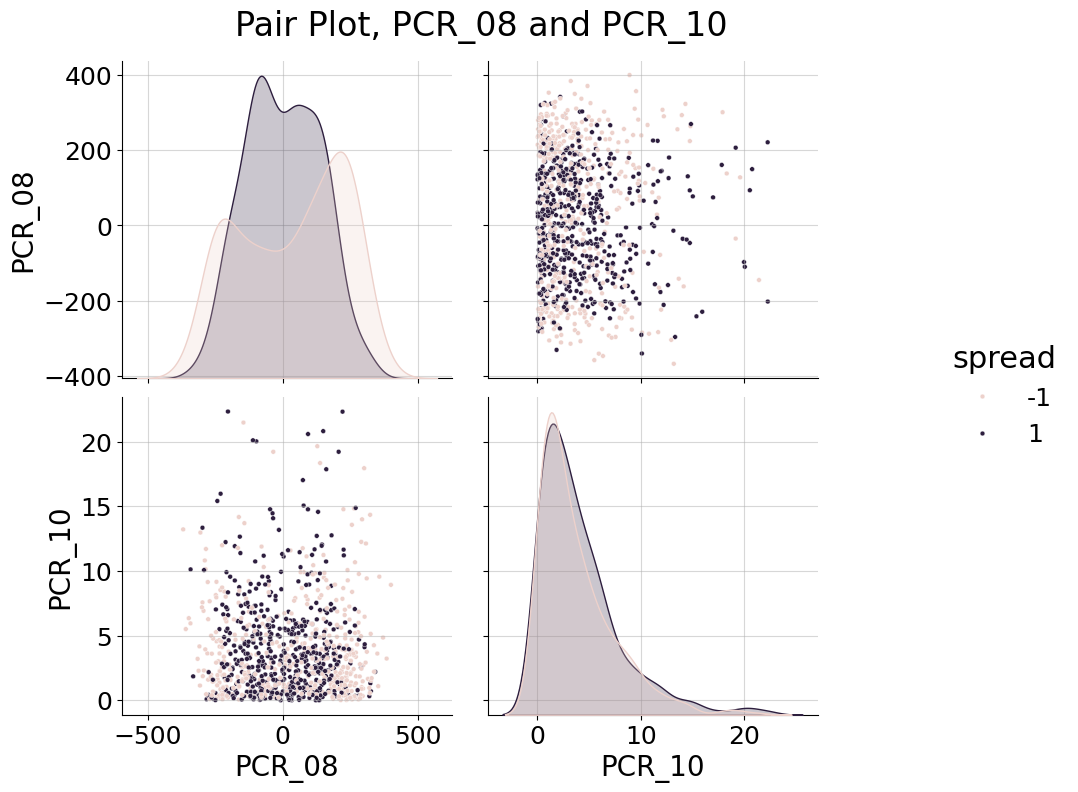

In [42]:
PAIRS = [
  ["PCR_01", "PCR_02"],
  ["PCR_01", "PCR_08"],
  ["PCR_01", "PCR_10"],
  ["PCR_02", "PCR_08"],
  ["PCR_02", "PCR_10"],
  ["PCR_08", "PCR_10"]
]

# go over each pair, create pairplot.

for pair in PAIRS:
  g=sns.pairplot(train,vars=pair, hue="spread", plot_kws={"s": 12})
  g.fig.suptitle(f"Pair Plot, {pair[0]} and {pair[1]}", y=1.04)
  for ax in np.ravel(g.axes):
    ax.grid(alpha=0.5)
  g.fig.set_size_inches(12,8)


#(Q9)

In [43]:
# calculate correlation between PCR01, PCR06 and spread
corr = train[['PCR_01', 'PCR_08', 'spread']].corr()

# display the correlations
corr[['spread']].loc[['PCR_01', 'PCR_08']]

,spread
PCR_01,0.023118
PCR_08,-0.100477


# Task C

In [68]:
# knn.py

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator,ClassifierMixin
from scipy.spatial.distance import cdist


class kNN(BaseEstimator, ClassifierMixin):

  def __init__(self, n_neighbors:int = 3):
    self.n_neighbors = n_neighbors

  def fit(self, X, y):
    self.X_train = np.copy(X)
    self.y_train = np.copy(y)
    return self

  def predict(self, X):
    #calculate the distances
    distances = cdist(X, self.X_train, metric='euclidean')
    #find the the k nearest neighbors
    nearest_indices = np.argsort(distances, axis=1)[:, :self.n_neighbors]
    #gather the nearest neighbors labels
    nearest_labels = self.y_train[nearest_indices]
    #using the sign of the sum, predict the most common label
    predictions = np.sign(nearest_labels.sum(axis=1))
    return predictions

# Task D - (Q11)

In [47]:
# create dataset with only the relevant features and label
temp_pcr = train.loc[:, ['PCR_01', 'PCR_08']]
spread_label = train.loc[:,['spread']]

# create 1nn model and fit the data
knn_1 = kNN(1)
knn_1.fit(temp_pcr,spread_label)

kNN(n_neighbors=1)

In [48]:
def visualize_clf(clf, X, Y, title,
                  xlabel, ylabel,
                  marker_size=50,
                  grid_length=300,
                  linewidths=None):
    import matplotlib.pyplot as plt
    import pandas as pd
    from matplotlib.colors import ListedColormap

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    # For internal use here, make sure labels are 0 and 1
    Y = np.ravel(Y).astype(int)
    labels = set(Y)
    assert len(labels) == 2, "Can only visualize two unique labels"

    if labels == set([-1,1]):
      Y = (Y + 1) // 2
      labels = set(Y)

    assert labels == set([0,1]), "Could not handle given labels"

    plt.figure(figsize=(8, 8))

    # Parameters
    n_classes = 2
    markers = ["D", "o"]
    palette = sns.color_palette("hls", 2)
    custom_cmap = ListedColormap(palette.as_hex())

    x_delta = np.abs(X[:, 0].max() - X[:, 0].min()) * 0.1
    y_delta = np.abs(X[:, 1].max() - X[:, 1].min()) * 0.1
    x_min, x_max = X[:, 0].min() - x_delta, X[:, 0].max() + x_delta
    y_min, y_max = X[:, 1].min() - y_delta, X[:, 1].max() + y_delta
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_length),
                         np.linspace(y_min, y_max, grid_length))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cs = plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.35)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.75)

    # Plot the training points
    for i, color, marker in zip(labels, palette, markers):
        idx = np.where(Y == i)
        plt.scatter(X[idx, 0], X[idx, 1], color=color,
                    marker=marker,
                    edgecolor='white', s=marker_size,
                    linewidths=linewidths)

    plt.title(title, fontsize=20)
    plt.axis("tight")
    plt.show()

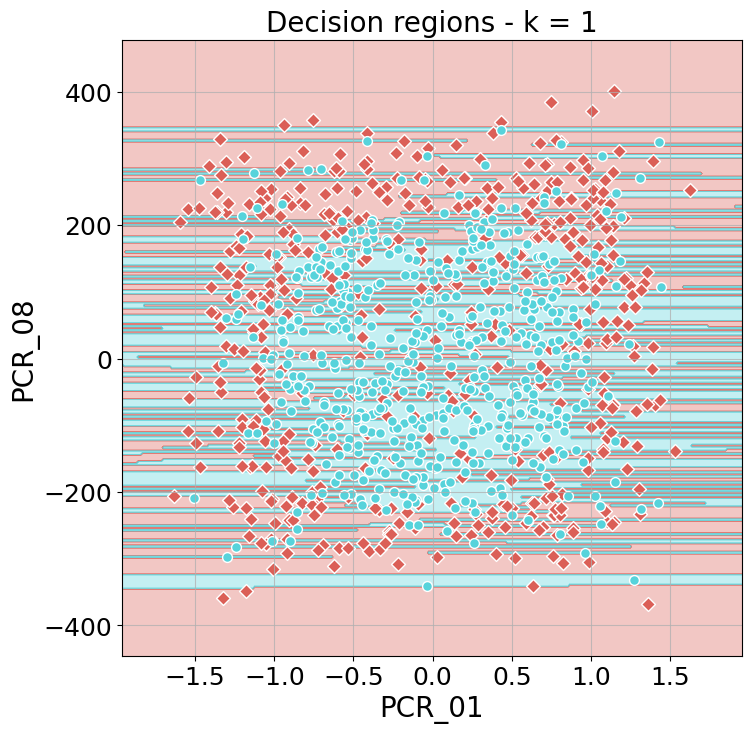

In [49]:
visualize_clf(knn_1, temp_pcr, spread_label, "Decision regions - k = 1", 'PCR_01','PCR_08')

In [50]:
knn_1.score(temp_pcr, spread_label)

1.0

In [51]:
knn_1.score(test.loc[:,['PCR_01','PCR_08']], test.loc[:,['spread']])

0.616

#(Q12)

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

# scale the temp_pcr fields and fit 1nn model again
scaler.fit(temp_pcr)
train_pcr_normal = scaler.transform(temp_pcr)
knn_1.fit(train_pcr_normal , spread_label)

kNN(n_neighbors=1)

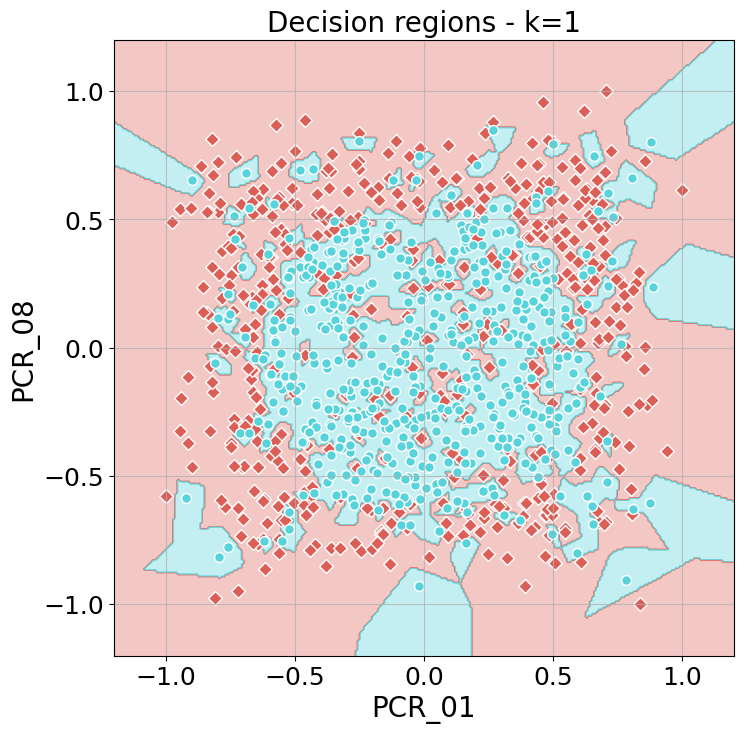

Training score: 1.0
Test score: 0.68


In [53]:
# visualize results and calc score on train data
visualize_clf(knn_1, train_pcr_normal, spread_label, "Decision regions - k=1", 'PCR_01', "PCR_08")
train_score = knn_1.score(train_pcr_normal, spread_label)

# scale test data and calc score on test data
test_pcr_normal = scaler.transform(test.loc[:,['PCR_01','PCR_08']])
test_score = knn_1.score(test_pcr_normal, test.loc[:,['spread']])

print(f"Training score: {train_score}")
print(f"Test score: {test_score}")

#(Q13)

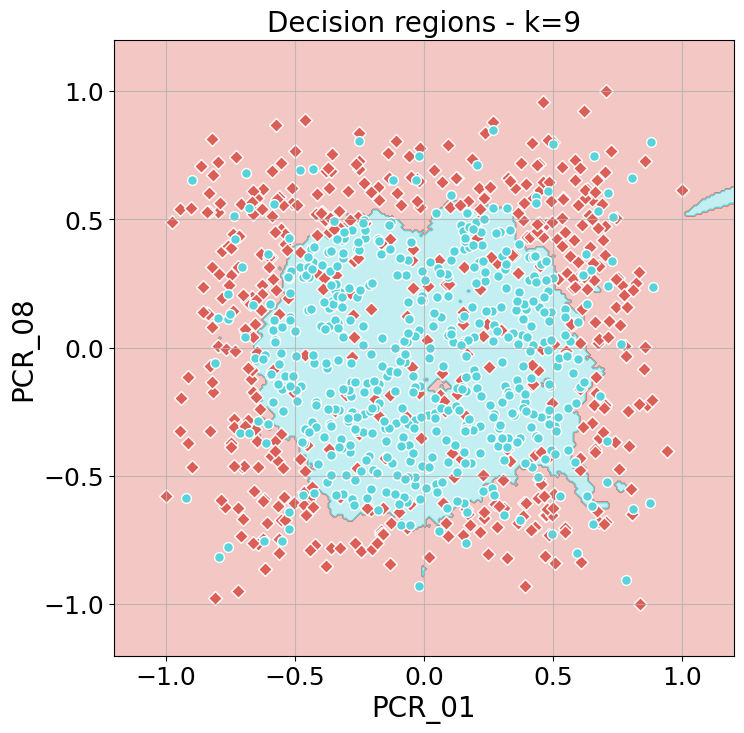

Training score: 0.797
Test score: 0.796


In [54]:
# create 9nn model and fit on normalized train data
knn_9 = kNN(9)
knn_9.fit(train_pcr_normal , spread_label)

# visualize result and calc train score
visualize_clf(knn_9, train_pcr_normal, spread_label, "Decision regions - k=9", 'PCR_01', "PCR_08")
train_score = knn_9.score(train_pcr_normal, spread_label)

# calc score on normalized test data
test_pcr_normal = scaler.transform(test.loc[:,['PCR_01','PCR_08']])
test_score = knn_9.score(test_pcr_normal, test.loc[:,['spread']])

print(f"Training score: {train_score}")
print(f"Test score: {test_score}")

# Task E

In [55]:
# add the SpecialProperty feature and drop blood type
train['SpecialProperty'] = train["blood_type"].isin(["O+", "B+"]).astype(int)
train = train.drop("blood_type", axis=1)


#For every Continuous feature, plot two histograms

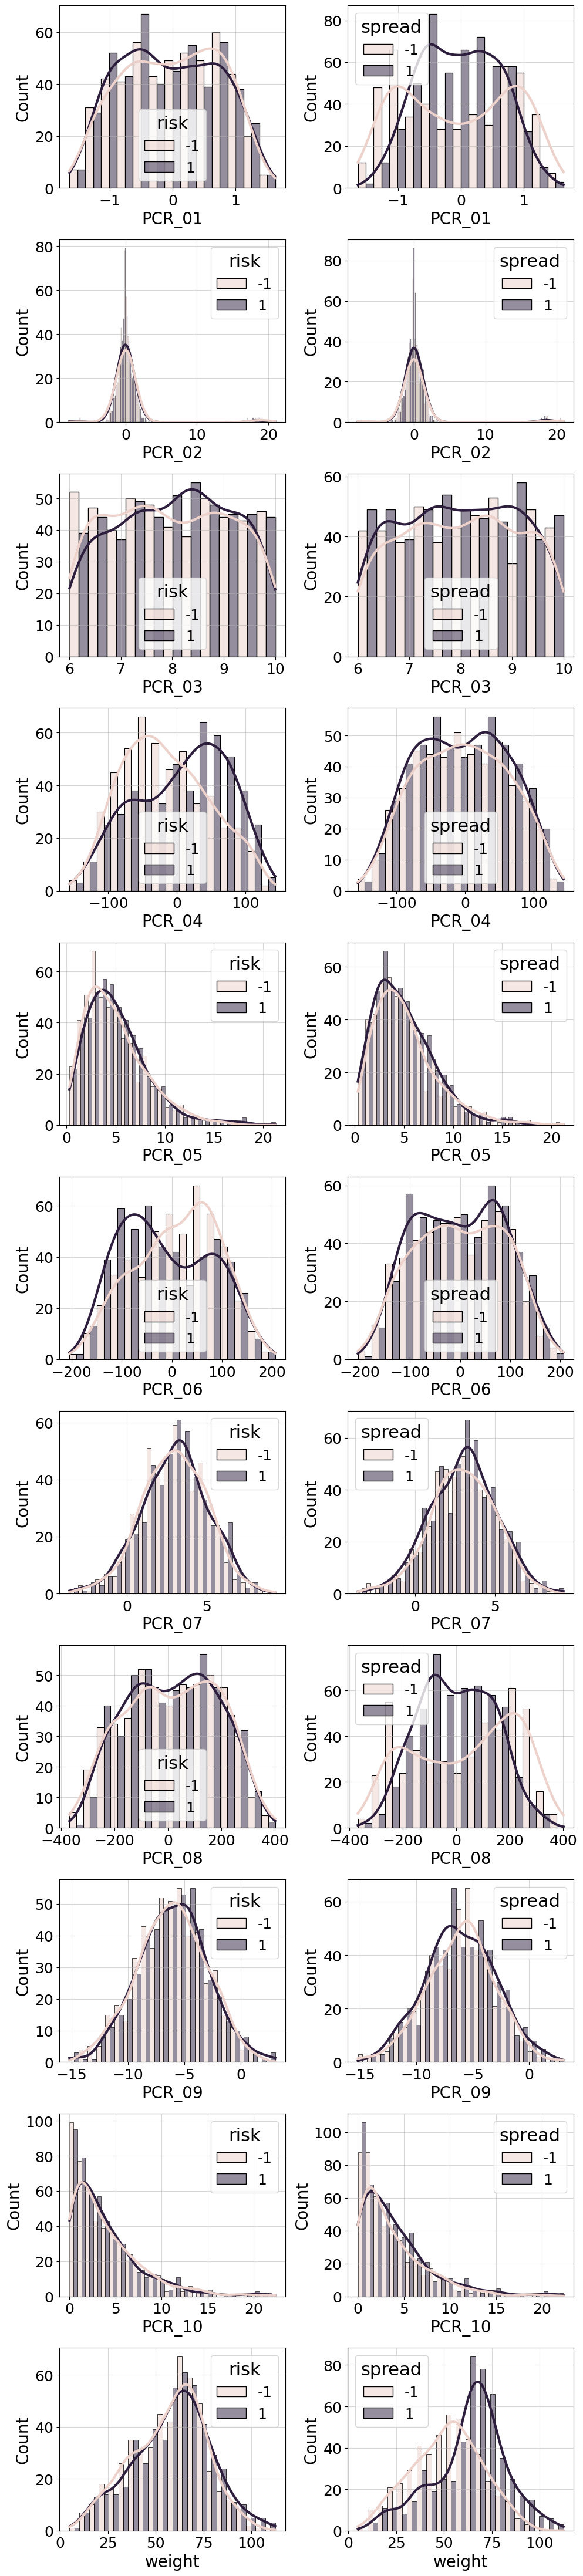

In [56]:
COL_NAME = ['PCR_01','PCR_02','PCR_03','PCR_04','PCR_05','PCR_06','PCR_07','PCR_08','PCR_09','PCR_10','weight']
COLS, ROWS = (2, len(COL_NAME))
plt.figure(figsize=(5 * COLS, 4 * ROWS))

for row in range(ROWS):
     column = COL_NAME[row]
     for j, cls in enumerate(["risk", "spread"]):
        plt.subplot(ROWS,COLS, row * COLS + 1 + j)
        isContinuous = "float" in train[column].dtype.name
        sns.histplot(data=train, x=column, hue=cls, line_kws={"linewidth": 3},
                          kde=isContinuous, multiple="dodge" if isContinuous else "dodge")
        plt.grid(alpha=0.5)

plt.tight_layout()

#(Q17)

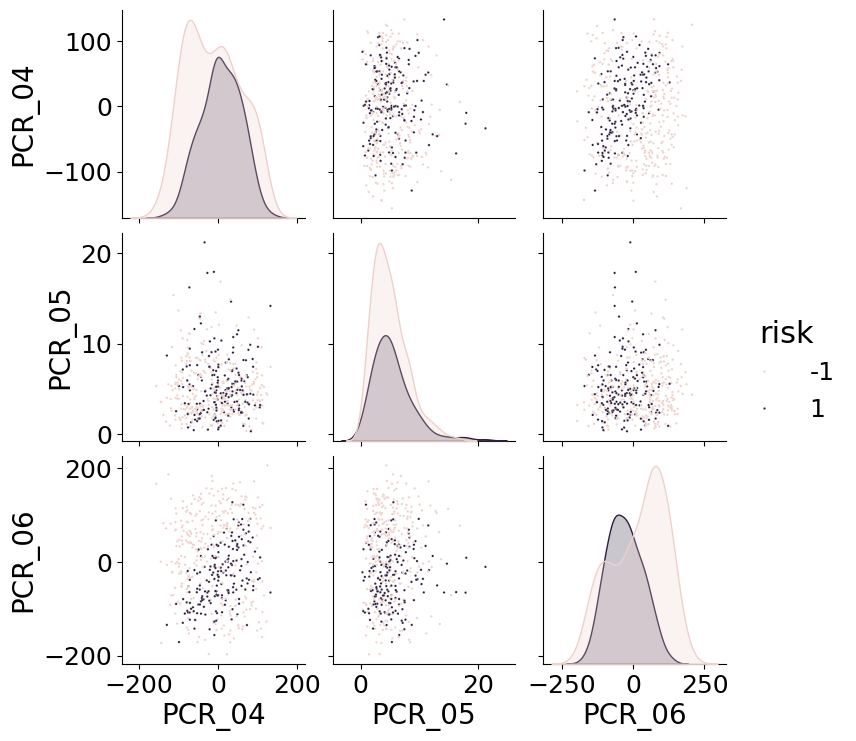

In [59]:
# divide dataset to samples with SpecialProperty = True and SpecialProperty = False
df_true = train[train['SpecialProperty'] == True] #O+ and B+
df_false = train[train['SpecialProperty'] == False] #else

# plot pairplot for the chosen features in the question for df_true
selected_pcr = ['PCR_04', 'PCR_05', 'PCR_06']
sns.pairplot (df_true[selected_pcr + ["risk"]],
    plot_kws={"s": 3}, hue="risk")

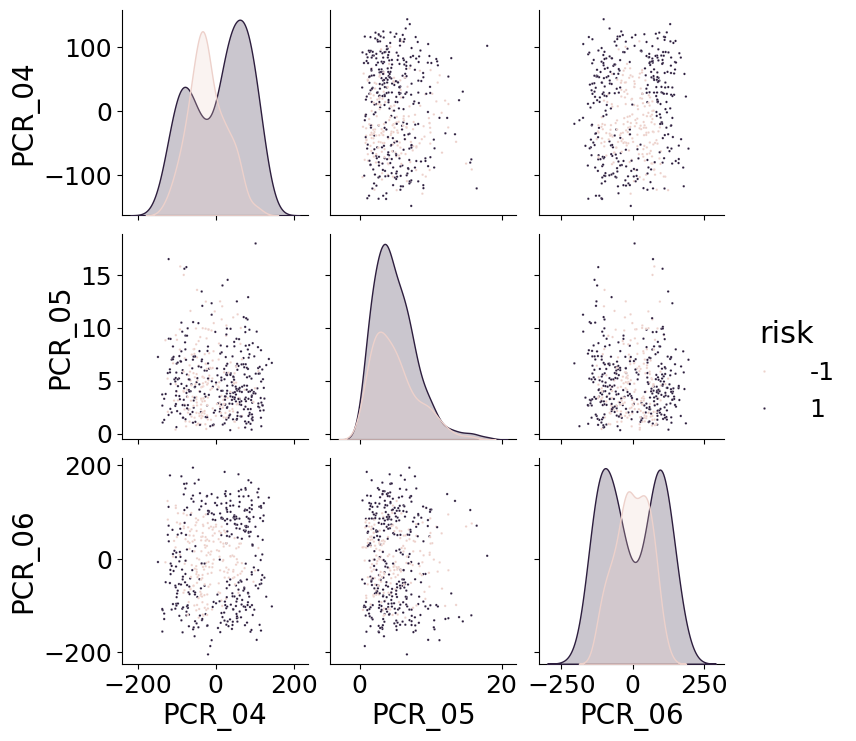

In [60]:
# plot for df_false
sns.pairplot (df_false[selected_pcr + ["risk"]],
    plot_kws={"s": 3}, hue="risk")

#(Q18)

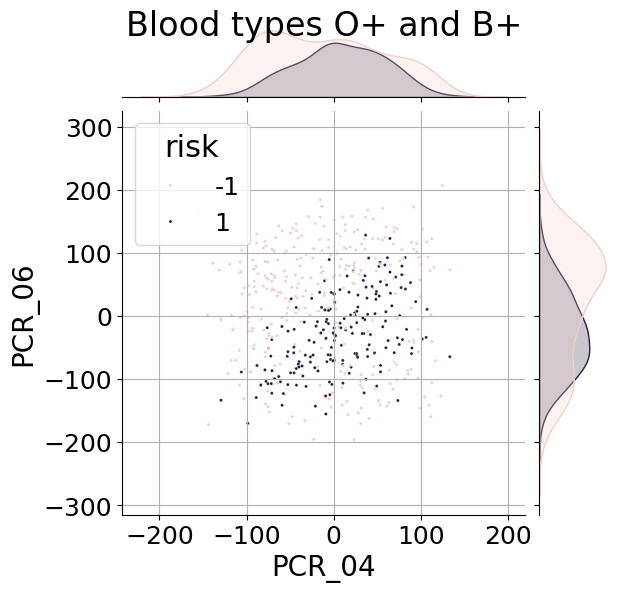

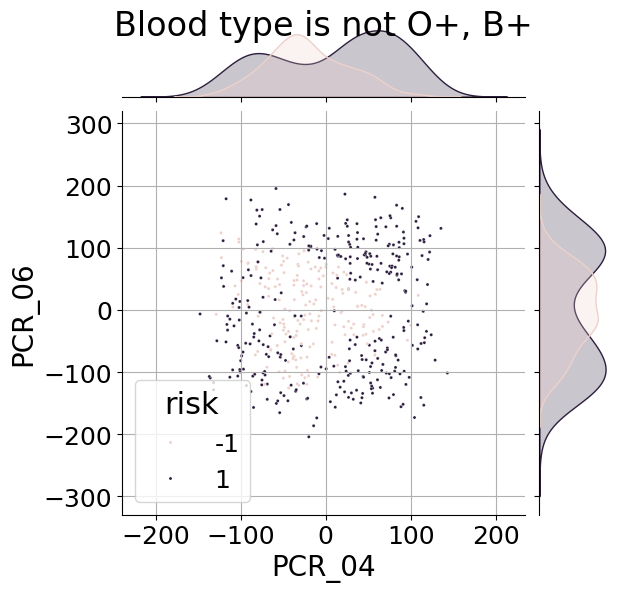

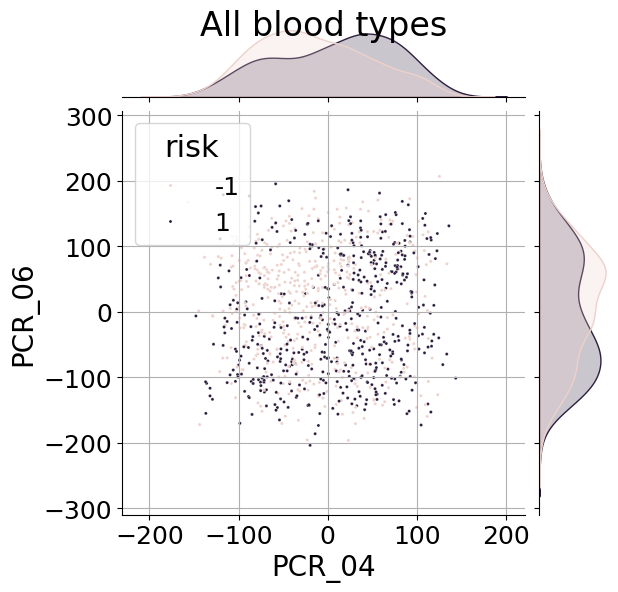

In [61]:
# jointplot for df_true
join1 = sns.jointplot(data=df_true, x='PCR_04', y='PCR_06' , hue='risk',  kind='scatter', s=5)
join1.fig.suptitle('Blood types O+ and B+')
plt.subplots_adjust(top=0.95)
join1.ax_joint.grid(True)
plt.show()

# jointplot for df_false
join2 = sns.jointplot(data=df_false, x='PCR_04', y='PCR_06' , hue='risk',  kind='scatter', s=5)
join2.fig.suptitle('Blood type is not O+, B+')
plt.subplots_adjust(top=0.95)
join2.ax_joint.grid(True)
plt.show()

# jointplot for train df
join3 = sns.jointplot(data=train, x='PCR_04', y='PCR_06' , hue='risk',  kind='scatter', s=5)
join3.fig.suptitle('All blood types')
plt.subplots_adjust(top=0.95)
join3.ax_joint.grid(True)
plt.show()

In [62]:
def plot3d(df, colX, colY, colZ, title, hue=None, s=1):
  %matplotlib inline

  fig = plt.figure(figsize=(20, 4))
  axes = [fig.add_subplot(1, 4, 1, projection='3d'),
          fig.add_subplot(1, 4, 2, projection='3d'),
          fig.add_subplot(1, 4, 3, projection='3d'),
          fig.add_subplot(1, 4, 4, projection='3d')]

  palette = sns.color_palette("hls", 2)

  for i,ax in enumerate(axes):
    if hue is None:
      ax.scatter3D(df[colX], df[colY], df[colZ], color=palette[0], s=s)
    else:
      idx = df[hue] == True
      df1 = df[idx]
      df2 = df[~idx]

      ax.scatter3D(df1[colX], df1[colY], df1[colZ], color=palette[0], s=s)
      ax.scatter3D(df2[colX], df2[colY], df2[colZ], color=palette[1], s=s)

    if i == 3 or i == 1:
      ax.set_xlabel(colX, labelpad=20)
      ax.set_ylabel(colY, labelpad=20)
    else:
      ax.xaxis.set_ticklabels([])
      ax.yaxis.set_ticklabels([])

    ax.view_init(elev=5., azim=45*i+15)

  axes[1].set_zlabel("\n" + colZ, labelpad=1)

  plt.suptitle(title)
  plt.subplots_adjust(wspace=0.1, top=0.99)
  plt.show()

#Q19


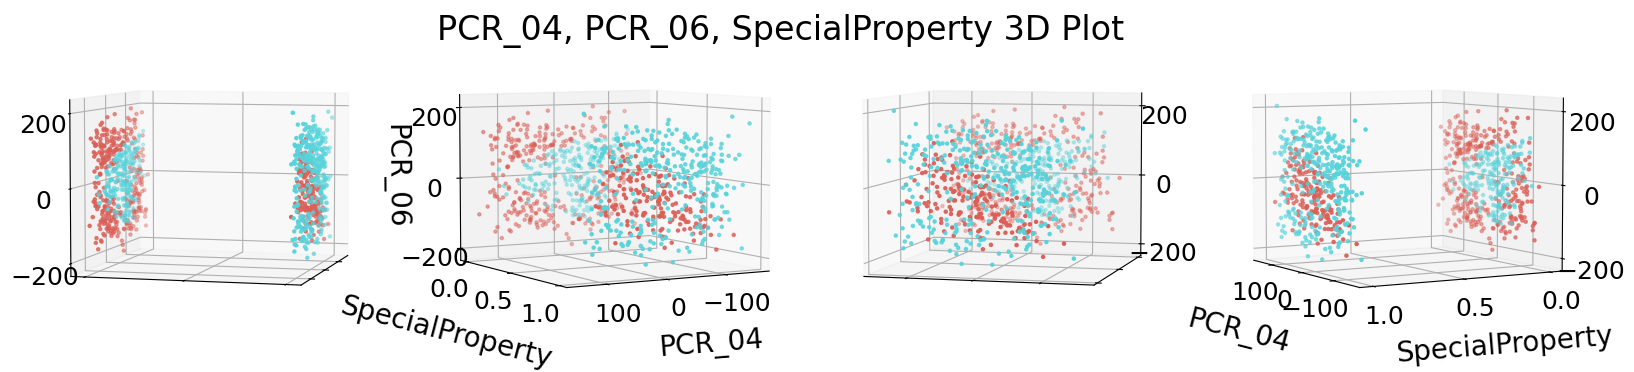

In [63]:
plot3d(train, "PCR_04", "SpecialProperty", "PCR_06", title="PCR_04, PCR_06, SpecialProperty 3D Plot", hue="risk", s=5)

#Task F

In [64]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Initialize scalers
mm_scaler = MinMaxScaler(feature_range=(-1,1))
std_scaler = StandardScaler()

# Normalize columns with the correct scalers
train[['PCR_01', 'PCR_03', 'PCR_04', 'PCR_06', 'PCR_08']] = mm_scaler.fit_transform(train[['PCR_01', 'PCR_03', 'PCR_04', 'PCR_06', 'PCR_08']])
train[['PCR_02', 'PCR_05', 'PCR_07', 'PCR_09', 'PCR_10']] = std_scaler.fit_transform(train[['PCR_02', 'PCR_05', 'PCR_07', 'PCR_09', 'PCR_10']])


#Task H

In [65]:
# prepare.py

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

FILL_NA_FIELDS = ["PCR_02", "household_income"]
SPECIAL_PROPERTY_BLOODTYPES = ["O+", "B+"]
MINMAX_NORMALIZE_FIELDS = ["PCR_01","PCR_03","PCR_04","PCR_06","PCR_08"]
STANDARD_NORMALIZE_FIELDS = ["PCR_02","PCR_05","PCR_07","PCR_09","PCR_10"]

# Helper function, makes a list of medians for required fields
def calc_fields_median(training_data, fields):
  medians = []

  for field in fields:
    medians.append(training_data[field].median())

  return medians

def prepare_data(training_data, new_data):
  # We will work on a copy of new_data to not change it
  new_data_processed = new_data.copy()

  # Calculate required medians from training_data to fill new_data
  medians = calc_fields_median(training_data, FILL_NA_FIELDS)

  # Fill copy of new_data null values with medians calculated before.
  for field, field_median in zip(FILL_NA_FIELDS, medians):
    new_data_processed[field] = new_data_processed[field].fillna(field_median)

  # Calculate Special Property
  new_data_processed['SpecialProperty'] = new_data.copy()["blood_type"].isin(SPECIAL_PROPERTY_BLOODTYPES).astype(int)

  # Initialize scalers
  mm_scaler = MinMaxScaler(feature_range=(-1,1))
  std_scaler = StandardScaler()

  # Apply scalers on required columns
  new_data_processed[MINMAX_NORMALIZE_FIELDS] = mm_scaler.fit_transform(new_data_processed[MINMAX_NORMALIZE_FIELDS])
  new_data_processed[STANDARD_NORMALIZE_FIELDS] = StandardScaler().fit_transform(new_data_processed[STANDARD_NORMALIZE_FIELDS])

  return new_data_processed



#Apply the function to both the train and test sets

In [66]:
from google.colab import files

# Prepare training set according to itself
train_df_prepared = prepare_data(train_df, train_df)

# Prepare test set according to the raw training set
test_df_prepared = prepare_data(train_df, test_df)


#Download the preprocessed datasets as CSV

In [67]:
# Download processed train Dataset
train_df_prepared.to_csv("train_df_prepared.csv")
files.download("train_df_prepared.csv")

# Download processed test Dataset
test_df_prepared.to_csv("test_df_prepared.csv")
files.download("test_df_prepared.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>